在本章中，我们将通过一种计算方法开始我们基于Python的GPU实践。从这个角度来看，重要的是要理解，计算方法主要集中在计算问题的解决，作为一系列的步骤：问题大纲，问题解决方案，编程的基本解决方案的问题，最后，测试其有效性。在这本书中，我们将遵循这种方法来解决我们所有的计算问题，我们试图通过GPU加速编程来解决这些问题。

C编程爱好者将被鼓励使用CUDA-C在其程序代码中调用NVIDIA GPU，而Python编程爱好者将被鼓励使用PyCUDA在其程序代码中调用NVIDIA GPU。我们首先从了解CUDA-C程序的工作原理开始。CUDA程序及其组件背后的基本概念将通过一些基本示例进行讨论，这些示例将帮助您向PyCUDA环境过渡。PyCUDA将用实际的方法进行解释，并与CUDA进行比较。我们关注PyCUDA相对于CUDA的适用性偏好，这与Python语法的简单性和强大性有关。

为便于学习，本章分为以下几个部分：
- 理解CUAD-C/C++的简单示例
- 在现有CUDA环境中安装PyCUDA for Python
- 在Python IDE上配置PyCUDA
- PyCUDA中的计算如何在Python上工作
- 比较PyCUDA和CUDA——还原的介绍性观点
- 编写第一个PyCUDA程序来计算通用解决方案
- 关于计算问题解决的有用练习

# 理解CUAD-C/C++的简单示例

到现在为止，你必须知道CUDA C/C++的计算优势，正如我们之前的讨论。C/C++与CUDA相结合，可以修改源代码的部分以加速计算结果。实现CUDA代码所需的主要步骤将通过GPU程序进行探索。

从现在开始，请在IDE上手动键入本书中使用的代码。直接从PDF中复制和粘贴将破坏代码中的缩进，使其无法部署。

首先，让我们来看看下面的传统C++程序，它使用双精度乘以两个数组元素。我们将在CPU上的5亿个元素上运行内核。p和q阵列的所有元素分别设置为24和12。

下面是我们刚才描述的C++程序（cpu_multiply.cpp):

现在我们初始化数组：

使用以下命令编译和运行前面的程序：

从前面的代码可以看出，乘法函数的CPU执行时间是1.34016秒。CPU执行时间可以是可变的。

现在让我们来看看相同程序的GPU版本。

在第4章GPU编程基础中，我们简要讨论了线程、块和网格的概念。因此，要在定义内核的GPU全局函数上设置索引，我们使用以下声明：

我们使用的变量定义如下：

请注意，前面的网格和块声明都是一维的（1D）。

一维网格和二维块可以声明如下：

对于一维网格和三维块，我们可以使用以下方法：

为了确保线程同步，我们还可以使用`__syncthreads()`来确保块中的所有线程都通过内核中定义的if语句。如果不满足If条件，则块中的所有线程都不会通过它。

在我们的主程序中，我们使用`cudaMalloc`专门为GPU变量分配内存。在这种情况下，我们必须指定将变量从CPU传输到GPU，并将计算结果再次带回CPU。在修订版中，我们还使用统一内存分配（`cudaMallocManaged`）来支持从CPU或GPU访问变量。修订后的代码也包含在本节中修订后的CUDA示例的注释中。

调用GPU内核函数时，我们使用以下语法：

变量定义如下：
- `multiply`是我们内核的名字
- `Threads_per_block` 是每个块中的线程数，即每个块的尺寸
- `Blocks_per_grid` 是网格内的块数，换句话说，就是网格的尺寸

此外，我们还可以选择在调用内核时为共享内存使用第三个参数。

`args`是指我们传递给GPU内核函数的参数，该函数将在GPU上进行计算，以便使用多线程进行并行计算。

具有整数向量数据类型的`dim3`变量也可用于指定每个块的线程数或每个网格的块数。它们可以声明如下：

32 x 32是每个块1024个线程。

我们计算块的数量，以获得至少N个线程，以便处理N个元素（本例中为5亿个元素），每个块使用1024个线程。我们将N除以每个块的线程数（块大小），如果N不是每个块线程数的倍数，则将其四舍五入。

还要注意，我们可以在同一个程序中同时使用`printf`或`cout`语句。

以下是CUDA（gpu_multiply.cu):

下面的代码部分显示了使用`cudamaloc`分配GPU设备内存：

在为CPU/主机拷贝分配内存之后，现在让我们为两个数组分配两个值。`cudaMemcpyHostToDevice`函数将主机数据传输到设备：

现在我们调用CUDA内核，并在GPU上传递计算所需的参数：

您还可以使用gpu同时计算一个基本的乘法表到一个巨大的范围。您所要做的就是添加第三个数组，例如r，并将其传递给GPU以用作`gpu_r. n2`是一个变量，表示要为其显示表的数字，您还必须声明接受该数字作为用户输入：

以下代码段显示GPU设备名称并报告计算时间：

最后，我们将清除CPU和GPU内存分配：

使用以下命令编译和运行:gpu_multiply.cu

尽管在前面的示例中，GPU版本的速度快了28.8倍，但实际的计算时间取决于整个操作，包括CPU和GPU之间的数据传输。这款来自NVIDIA的Titan X版本属于2015年发布的Maxwell架构。为了获得整个计算时间的完整估计，我们可以使用以下基于终端的评测命令nvprof：

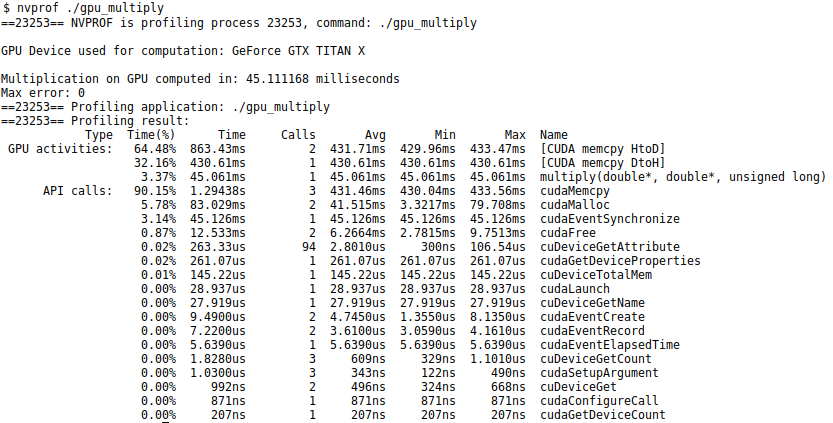

您可以在第一行看到，我们的GPU内核multiply的实际计算时间是45.061毫秒。大部分时间被CPU和GPU之间的数据传输以及cudaMemcpy的使用所消耗，这有助于这些传输。

自从推出Pascal GPU和更高版本的体系结构以来，统一内存功能得到了显著的改进。尽管我们使用的Titan X GPU属于Pascal之前的Maxwell体系结构，但我们也修改并测试了前面的GPU代码以获得统一内存：

注释掉`cudamaloc`|分配，因为我们将使用统一内存：

使用`cudaMallocManaged`的变量内存分配允许从CPU和GPU进行访问：

将阵列传输到GPU设备后，我们现在初始化事件以记录计算时间：

调用内核后，我们完成计算时间的记录：

我们不需要使用cudaMemcpyDeviceToHost（注释）的以下行，因为我们使用的是统一内存：

我们再次运行`nvprof`来检查输出和分析：

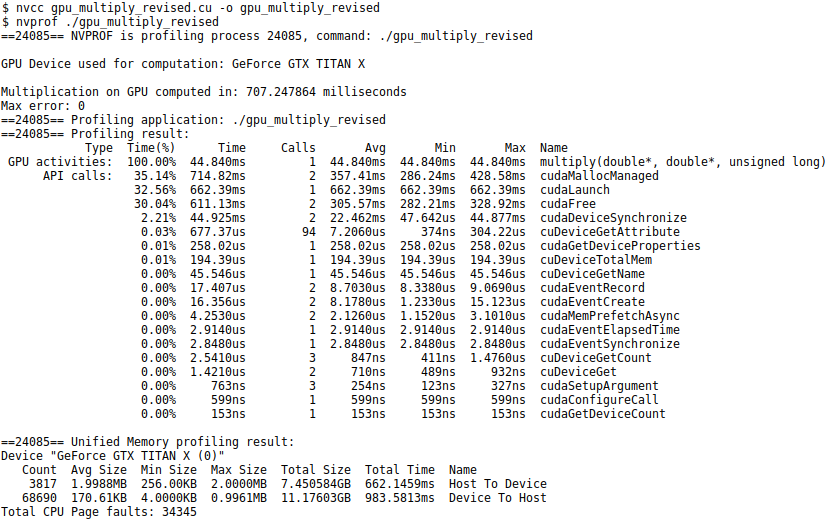

优化GPU+CPU的执行时间在很大程度上取决于并行缩减、共享内存和全局内核内动态并行的有效使用。这些措施确保了GPU上可用硬件资源的有效利用，以尽可能降低总体执行时间。这对于职业环境来说是非常必要的。

另外，一个好的措施是连接一个次级低端GPU到你的PC显示器上，在计算过程中读取数据。这样，您就可以减轻主GPU不必要的资源共享（显示）负担，并将其全部功能用于执行计算。

在下一节中，我们将开始探索如何利用这个简单的Python代码的CUDA API。当我们开始使用PyCUDA进行计算时，我们将探索前面提到的功能和并行特性的范围，特别是在Python中。PycUDA允许您同时使用CUDA—C/C++和Python代码，我们的重点将是利用最新的Python编程方法来实现Nvidia GPU。

# 在现有CUDA环境中安装PyCUDA for Python

既然我们已经了解了CUDA的安装和实现，现在开始PyCUDA的Python安装过程就更容易了。您也不需要安装Python，因为新安装的ubuntu18.04linux操作系统已经提供了Python（2.x和3.x）。

我们还了解了Anaconda及其设置，还可以使用python2.x或3.x，这在现有的Anaconda配置中很容易获得。设置PyCUDA可以在现有的Python设置中实现CUDA内核，然后在nvidiagpu上使用它进行计算。

主要有两种安装方法。

## 基于Anaconda的PyCUDA安装

这是一种推荐的方法来开始PyCUDA的生产力环境。通过使用虚拟环境，您可以安全地试验编程技能，而不会影响系统范围的Python设置。

要在Anaconda中设置PyCUDA，让我们通过终端上的以下命令将PyCUDA与conda一起安装。输入y继续。根据Anaconda装置的更新状态，第一个命令是必要的：

## pip–基于Python的系统范围PyCUDA安装

要在系统范围内安装绑定到现有Python库的PyCUDA，我们首先必须安装pip，这是一个安装Python包的工具。

要安装Pip for Python 3.x，请使用以下命令：

Python2.x的pip可以通过以下方式安装：

以下是pip开发者的一个重要提示：

注意，`pip install--user pycuda` 也执行与 `pip3 install--user pycuda` 相同的操作。

安装PyCUDA for Python 2.x的替代命令如下：

现在你有了一个用户指定的配置，可以在你的Ubuntu Linux系统上使用。在下一节中，我们将学习如何在PyCharm IDE上配置基于Conda和用户指定的系统范围配置。

# 在Python IDE上配置PyCUDA

在本书中，我们使用PyCharm作为我们首选的IDE，因为它的独特设计只关注Python编程语言。接下来的步骤具体用于两种场景，即使用现有的Conda环境和系统范围的设置。如果您喜欢不同的IDE，仍然可以使用这些步骤作为参考，因为过程非常相似。要使用PyCharm配置PyCUDA，我们将重新讨论前一章中讨论的两种安装包的方法。

## 基于Conda的虚拟环境

现在让我们用conda作为一个新的PyCharm纯Python项目来创建一个虚拟环境。执行以下步骤在PyCharm中创建和配置环境：

1. 启动PyCharm：

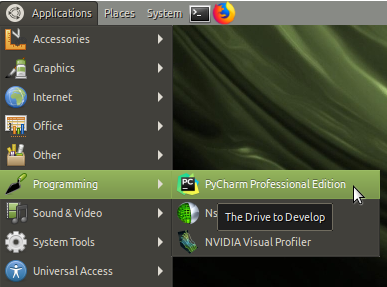

2. 从主菜单中选择“新建项目”：

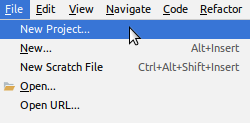

3. 现在确保新环境正在使用Conda:

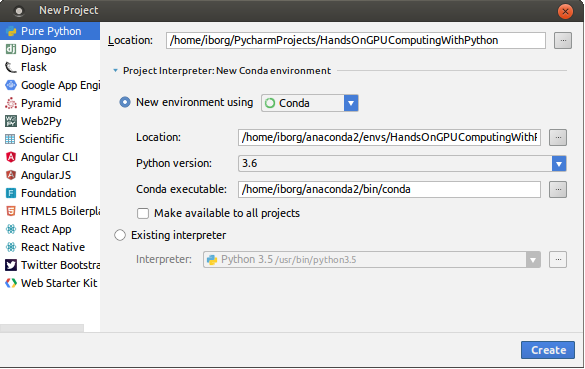

在创建Conda环境之后，您将拥有一个随时可用的PyCUDA开发环境。

现在可以在Python程序中导入pycuda了。正如您接下来看到的，当您开始键入import pycuda时，PyCharm会检测并推荐pycuda（<built-in>）：

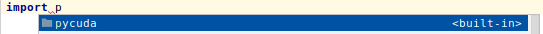

注意，<built-in>指的是Conda-wide pycuda包。在这个阶段，我们已经完成了在IDE上配置PyCUDA。
    
但是作为替代措施（可选），您还可以使用终端创建虚拟环境（正如我们在第5章的Jupyter安装中所看到的，在IDEs上为GPU编程设置环境）。在下面，我们使用新名称`HandsOnGPUComputingWithPython`创建一个新的虚拟环境，这个名称已经由PyCharm创建：

所有虚拟环境都是在Anaconda目录（$HOME/anaconda2或$HOME/anaconda3）中名为envs的目录中创建的。即使我们已经在Conda基础安装中安装了PyCUDA，您也可以选择激活新环境并在其中本地安装PyCUDA。如果您不想安装Conda-wide PyCUDA，并且只想将其保留在特定项目中，那么这将非常有用。

从终端使用以下命令激活虚拟环境并安装PyCUDA：

使用此本地PyCUDA配置时，请注意PyCharm将显示完整的路径，而不是<built-in>，因为它现在可以访问自己的本地PyCUDA环境：

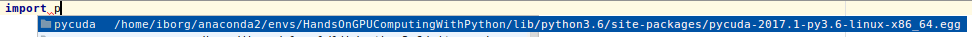

现在让我们来看看如何为PyCUDA完成一个带有pip的系统范围的安装。

## 基于pip的全系统环境

要为Python配置系统范围的PyCUDA安装，可以在PyCharm上创建新项目或更改系统解释器。按照以下步骤配置PyCharm以使用系统范围的Python安装：

1. 在PyCharm中创建新项目：

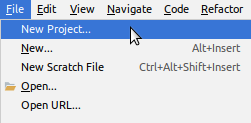

2. 我们现在将选择在Ubuntu上预装的系统级Python安装，而不是Conda环境：

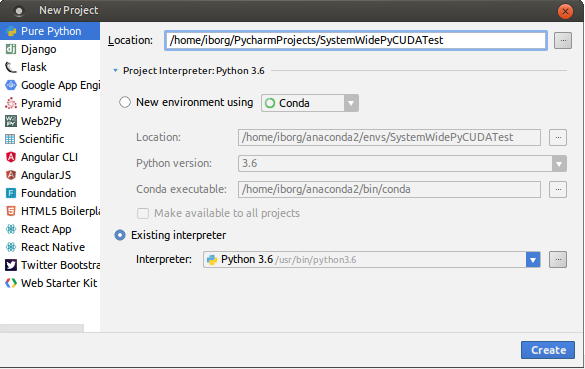

创建此环境后，现在可以开始在PyCharm上使用用户特定的系统范围的PyCUDA安装：

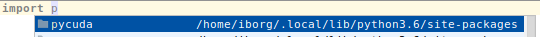

如果您想重新使用在虚拟环境中设置的基于Conda的PyCUDA项目，PyCharm仍然更愿意使用系统范围的配置。要使PyCharm再次识别基于Conda的PyCUDA包，必须执行以下步骤：

1. 首先，转到“文件”菜单中的“设置”：

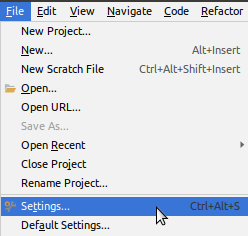

2. 现在单击“设置”窗口右上角区域显示的档位符号：

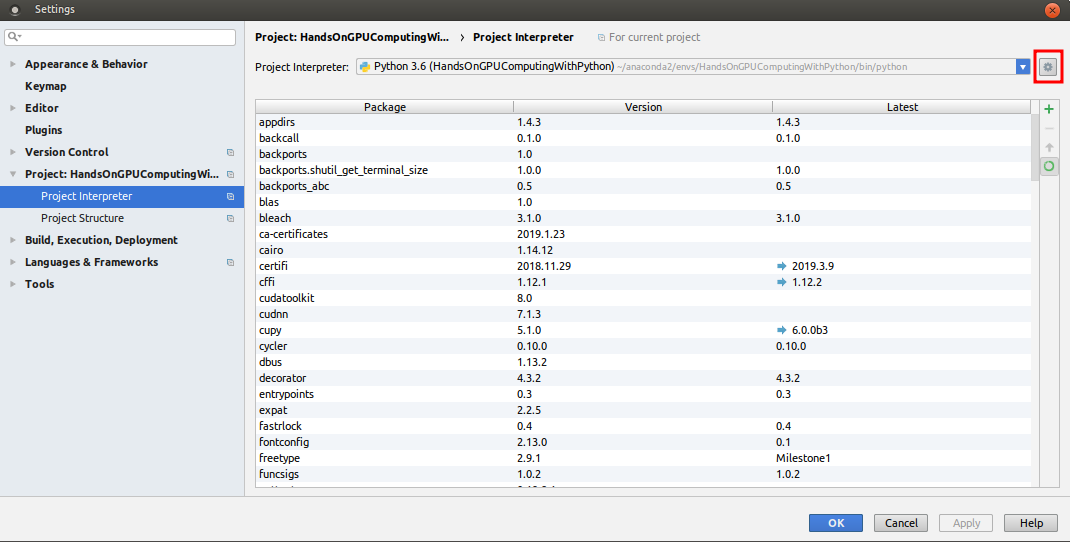

3. 单击Show All（全部显示）：

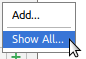

4. 从列表中选择项目解释器，并单击图标，当您使用鼠标悬停在所选解释器上时，该图标显示所选解释器的路径：

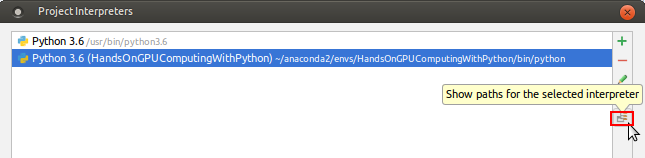

5. 删除PyCharm在系统范围内看到的用户指定路径。单击“确定”：

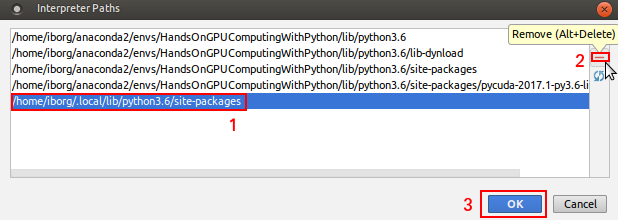

6. 在“项目解释器”窗口中再次单击“确定”。最后，在“设置”窗口中单击“应用”以使更改生效。
7. 现在，您可以再次开始使用特定于Conda的本地PyCUDA包：

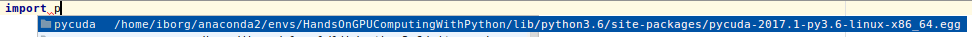

如果您想在两者之间切换，只需在系统解释器窗口中的Python 3.6/usr/bin/python3.6和基于Conda的虚拟环境之间切换：

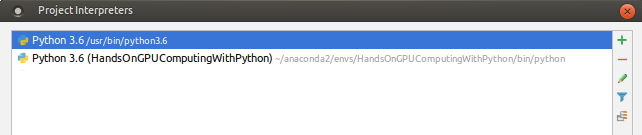

我们现在可以开始用PyCUDA计算了！

# PyCUDA中的计算如何在Python上工作

在我们的第一章中，我们强调计算是特定于应用程序的，是一种跨多学科领域计算任何可测量实体的技术。这些计算旨在解决现实世界场景中的实际计算问题，这就是为什么我们的重点是解决计算问题，以满足计算的主要目标。

- 计算：每个计算问题的答案都在于它的计算解。
- 加速计算：一个计算密集的问题需要一个加速的解决方案。

让我们了解PyCUDA如何帮助我们解决基于Python的GPU计算的无数计算问题，有或没有CUDA -C/C++代码。

在我们的第一个C++与CUDA示例之后，我们将使用类似的方法来研究一个非常简单的Python与PycUDA示例，与PyCharm一起动手。接下来，我们将把重点转向实际的GPU加速计算，用PyCUDA解决特定的计算问题。

执行以下步骤以在Python中创建一个简单的程序，该程序将使用值初始化两个数组，然后使用PyCharm IDE计算第三个数组，该数组的值将是两个数组中相应元素的乘积：

1. 如前所示启动PyCharm并创建一个新的空Python文件：

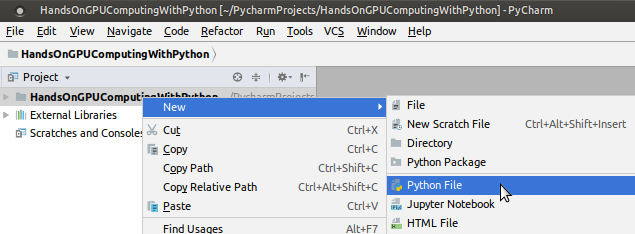

2. 现在使用以下代码。我们再次尝试以双精度使用5亿个元素：

In [1]:
import numpy as np
from timeit import default_timer as timer

N = 500000000 #500 Million Elements

# CPU Function to multiply two array elements and also update the results on the second array
def multiply(p_cpu, q_cpu):
    for i in range(N):
        q_cpu[i] = p_cpu[i] * q_cpu[i]

`default_timer` 用于计算CPU计算时间：

In [4]:
def main():
    #Initialize the two arrays of double data type all with 0.0 values upto N
    p = np.zeros(N, dtype=np.double)
    q = np.zeros(N, dtype=np.double)
    #Update all the elements in the two arrays with 23.0 and 12.0 respectively
    p.fill(23.0)
    q.fill(12.0)

    #Time the CPU Function
    begin = timer()
    multiply(p, q)
    numpy_cpu_time = timer() - begin

    #Report CPU Computation Time
    print("CPU function took %f seconds." % numpy_cpu_time)

    #Choose a random integer index value between 0 to N
    random = np.random.randint(0, N)
    #Verify all values to be 276.0 for second array by random selection
    print("New value of second array element with random index", random, "is", q[random])

In [5]:
if __name__ == "__main__":
    main()

CPU function took 310.236109 seconds.
New value of second array element with random index 488656457 is 276.0


在代码上单击鼠标右键，然后选择运行“conventional_python_..”：

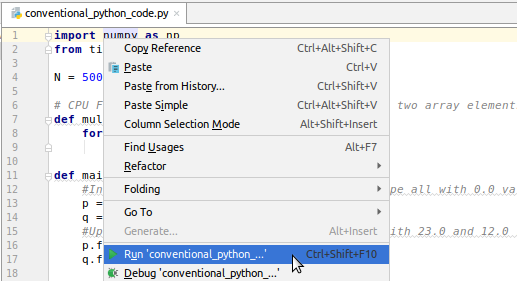

Python没有内置的数组支持，这就是我们为此导入numpy库的原因。这一次，我们发现CPU计算时间比我们在本章的第一节中在C++上看到的高很多倍。花了114.381630秒：

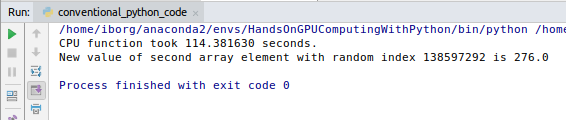

cProfile是一个基于命令行的Python分析器，类似于CUDA中的nvprof。使用以下命令，您可以分析包含基于GPU的分配的完整Python代码，并查找CPU+GPU计算时间：

要退出界面，请按Q。

对于我们在前面代码中使用的相同代码的PyCUDA版本，我们选择包含最少C代码的版本：

In [8]:
import pycuda.autoinit
import pycuda.driver as cudadrv
import numpy
import pycuda.gpuarray as gpuarray
from pycuda.elementwise import ElementwiseKernel

# Here, we multiply the two values and update all the elements of the second array with the new product

# Note that we pass C syntax into the ElementwiseKernel
multiply = ElementwiseKernel (
      "double *a_gpu, double *b_gpu",
      "b_gpu[i] = a_gpu[i] * b_gpu[i]",
      "multiply")

N = 500000000 # 500 Million Elements

a_gpu = gpuarray.to_gpu(numpy.zeros(N).astype(numpy.double))
b_gpu = gpuarray.to_gpu(numpy.zeros(N).astype(numpy.double))

MemoryError: cuMemAlloc failed: out of memory

以下代码段为两个数组的所有元素赋值，使用乘法函数计算并存储它们的乘积，然后打印结果和所用时间：

In [ ]:
a_gpu.fill(23.0)
b_gpu.fill(12.0)
begin = cudadrv.Event()
end = cudadrv.Event()

# Time the GPU function
begin.record()
multiply(a_gpu, b_gpu)
end.record()
end.synchronize()
gpu_multiply_time = begin.time_till(end)
random = numpy.random.randint(0,N)

# Randomly choose index from second array to confirm changes to second array
print("New value of second array element with random index", random, "is", b_gpu[random])

# Report GPU Function time
print("GPU function took %f milliseconds." % gpu_multiply_time)

GPU函数现在在62.38826毫秒内计算相同的操作：

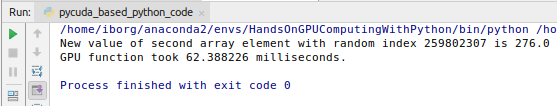

首先，我们从PyCUDA导入autoinit，它自动执行使CUDA准备好提交nvidiagpu计算内核所需的所有步骤。从PyCUDA中导入驱动模块，计算GPU的计算时间。PyCUDA自己的gpuarray模块被导入以用GPU初始化阵列。根据官方的PyCUDA文档，在GPUArray实例上计算所涉及的表达式可能有点效率低下，因为每个中间结果都会创建一个新的临时变量。因此，我们从PyCUDA导入elementwise模块，它包含一些工具来帮助生成内核，以便在一次传递中对一个或多个操作数的多级表达式求值。

为了更好地理解这一点，让我们删除elementwise内核，并尝试一个类似的操作，但是使用gpuarray模块：

In [ ]:
import pycuda.autoinit
import pycuda.gpuarray as gpuarray
import numpy as np
import pycuda.driver as cudrv

N = 500000000
begin = cudrv.Event()
end = cudrv.Event()
begin.record()
a_gpu = gpuarray.to_gpu(np.zeros(N).astype(np.double))
a_gpu.fill(23.0)
b_gpu=a_gpu*12.0
end.record()
end.synchronize()
pycuda_gpu_time = begin.time_till(end)
random = np.random.randint(0,N)

我们现在通过随机选择一个索引并报告计算时间来检查新的乘法乘积值：

In [9]:
print("Choosing second array element with index", random, "at random:", b_gpu[random])
print("\nGPU took %f milliseconds." % pycuda_gpu_time)

NameError: name 'random' is not defined

在GPU上计算结果大约需要2.5秒：

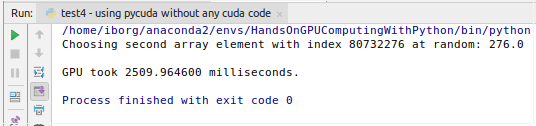

尽管这段代码看起来像是一个传统的Python程序，但它花了两秒多的时间才完成。所以，现在我们知道了使用elementwise内核的重要性。

现在让我们回到计算的核心概念：如何利用这种方法来解决计算问题？让我们选择一个问题场景，比如在生物统计学领域，它与生物数据的统计研究有关。假设我们想把一系列这样的生物大数据与另一系列关联起来。使用PyCUDA和其他GPU加速的Python模块，我们可以通过使用统计公式计算值来理解两个生物数据数组之间的关系。在我们演示了第一个PyCUDA程序之后，我们将在本章后面通过一个真实的例子进一步探讨这种方法。

# 比较PyCUDA和CUDA——Reduction的介绍性观点

在我们在PyCharm上编写第一个PyCUDA程序之前，让我们比较一下PyCUDA和CUDA在并行化方面的简单性。
在下表中，我们可以探索PyCUDA相对于CUDA的范围，以便了解PyCUDA对CUDA有利的场景：

<table border="1" style="border-collapse: collapse;width: 100%">
<tbody>
<tr>
<td class="CDPAlignCenter CDPAlign">
<p><strong>CUDA</strong></p>
</td>
<td class="CDPAlignCenter CDPAlign">
<p><strong>PyCUDA</strong></p>
</td>
</tr>
<tr>
<td>
<p>基于C/C++的编程语言</p>
</td>
<td>
<p>基于Python编程语言</p>
</td>
</tr>
<tr>
<td>
<p>用C/C++结合专用代码加速计算</p>
</td>
<td>
<p>使用Python为gpu接口CUDA和加速计算</p>
</td>
</tr>
<tr>
<td>
<p>Reduction 是CUDA的一个关键特性，对于最大化并行化和有效地利用线程非常重要</p>
</td>
<td>
<p>考虑到Reduction的重要性，PyCUDA的Reduction比CUDA简单得多。</p>
</td>
</tr>
</tbody>
</table>

## 什么是Reduction？

Reduction是一种优化策略，是对全局核的扩展。通过Reduction，您可以使用多个线程块并将计算分解为多个内核调用。因此，Reduction最大限度地提高了并行化程度，极大地减少了计算时间。

为了实现CUDA—C/C++的Reduction，需要用多行代码扩展`__global__`内核。

使用PyCUDA，您可以通过导入Reduction模块在单行中执行Reductionn。它被称为`ReductionKernel`，可以用GPUArrays实现。在PycUDA中，您也可以选择在实际的`__global__`内核本身使用CUDA C/C++还原。

在下一章中，我们将在比较PyOpenCL与CUDA和ROCm时再次讨论这个观点。

# 编写第一个PyCUDA程序来计算通用解决方案

让我们继续我们激动人心的旅程。现在是时候把我们的手弄脏，写我们的第一个PyCUDA程序，将计算一个通用的解决方案。请按照以下步骤开始：

1. 首先，在PyCharm中打开一个新文件：

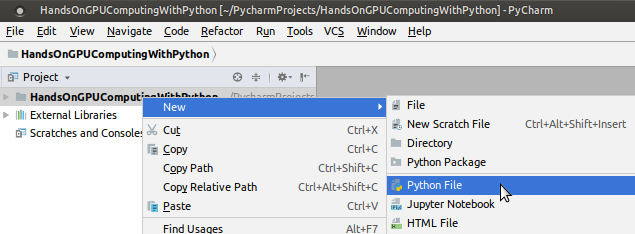

2. 现在使用以下代码从GPU设备本身打印`Hello World from NVIDIA GPU!`这是PyCUDA中的常规基本格式：

In [7]:
# Auto initialization for CUDA (can be done manually as well)
import pycuda.autoinit

# Importing SourceModule from the PyCUDA Compiler module
from pycuda.compiler import SourceModule

# Printing from the GPU device itself!
mod = SourceModule("""
__global__ void hello_from_nvidia_gpu()
{
printf("Hello World from NVIDIA GPU!");
}
""")

#Referencing the function for the GPU kernel
hello = mod.get_function("hello_from_nvidia_gpu")

#Invoking the NVIDIA GPU Kernel on a single thread in a single block
hello(block=(1, 1, 1), grid=(1, 1))

C:\Users\Administrator\AppData\Roaming\Python\Python37\site-packages\ipykernel_launcher.py:13: UserWarning: The CUDA compiler succeeded, but said the following:
kernel.cu
c:\program files\nvidia gpu computing toolkit\cuda\v10.1\include\crt\math_functions.h: warning C4819: ���ļ����������ڵ�ǰ����ҳ(936)�б�ʾ���ַ����뽫���ļ�����Ϊ Unicode ��ʽ�Է�ֹ���ݶ�ʧ
c:\program files\nvidia gpu computing toolkit\cuda\v10.1\include\crt\math_functions.h(825): warning C4819: ���ļ����������ڵ�ǰ����ҳ(936)�б�ʾ���ַ����뽫���ļ�����Ϊ Unicode ��ʽ�Է�ֹ���ݶ�ʧ
c:\program files\nvidia gpu computing toolkit\cuda\v10.1\include\crt\math_functions.h(1760): warning C4819: ���ļ����������ڵ�ǰ����ҳ(936)�б�ʾ���ַ����뽫���ļ�����Ϊ Unicode ��ʽ�Է�ֹ���ݶ�ʧ
c:\program files\nvidia gpu computing toolkit\cuda\v10.1\include\crt\math_functions.h(2622): warning C4819: ���ļ����������ڵ�ǰ����ҳ(936)�б�ʾ���ַ����뽫���ļ�����Ϊ Unicode ��ʽ�Է�ֹ���ݶ�ʧ
c:\program files\nvidia gpu computing toolkit\cuda\v10.1\include\crt\math_functions.h(3461): warning C4819: ���ļ

以下是此程序的输出：

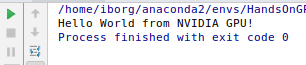

3. 我们还可以将同一程序修改为可自定义的线程和块分配格式：

In [10]:
# Auto initialization for CUDA
import pycuda.autoinit

# Importing SourceModule from the PyCUDA Compiler module
from pycuda.compiler import SourceModule

# For a single thread on a single block
N=1

4. 在这里，我们可以设置每个块的线程数和每个网格的块数：

In [11]:
# Setting threads per block. Here, it is set to 1
Threads_per_block = (int(1))

# Setting blocks per grid, also calculated as 1.
Blocks_per_grid = (int((N + Threads_per_block - 1) / Threads_per_block))

# Printing from the GPU device itself!
mod = SourceModule("""
__global__ void hello_from_nvidia_gpu()
{
printf("Hello World from NVIDIA GPU!");
}
""")

In [12]:
# Return the Function name in the get_function module
hello_from_nvidia_gpu = mod.get_function("hello_from_nvidia_gpu")

# Invoking the NVIDIA GPU Kernel
hello_from_nvidia_gpu(block=(Threads_per_block, 1, 1), grid=(Blocks_per_grid, 1))

输出类似于以下屏幕截图：

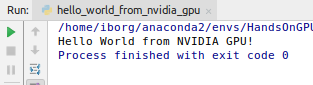

现在我们可以开始编写和测试我们自己的PyCUDA程序了，让我们看看如何使用PyCUDA来计算地解决问题，因为我们关注的是一种计算方法。

之前，我们探讨了一个使用ElementwiseKernel的示例。现在，我们修改它并创建一个新数组，其中包含基于新数学公式的所有值：

In [13]:
import pycuda.autoinit
import numpy
import pycuda.gpuarray as gpuarray
import pycuda.driver as drv
from pycuda.elementwise import ElementwiseKernel

# Here, we compute a mathematical formula
# Note that we pass C/C++ syntax into the ElementwiseKernel
compute = ElementwiseKernel(
      "double *a_gpu, double *b_gpu, double *c_gpu",
      "c_gpu[i] = (cos(a_gpu[i])*cos(a_gpu[i])) * (b_gpu[i]* b_gpu[i])+sin(a_gpu[i]*b_gpu[i])",
      "compute")

您可以在本节末尾找到实际公式：

In [17]:
N = 500000

# Threads_per_block = (int(1024))
# Blocks_per_grid = (int((N + Threads_per_block - 1) / Threads_per_block))
a_gpu = gpuarray.to_gpu(numpy.zeros(N).astype(numpy.double))
b_gpu = gpuarray.to_gpu(numpy.zeros(N).astype(numpy.double))
c_gpu = gpuarray.to_gpu(numpy.zeros(N).astype(numpy.double))
a_gpu.fill(24.0)
b_gpu.fill(12.0)
start = drv.Event()
end = drv.Event()
# Time the GPU function
start.record()
compute(a_gpu, b_gpu, c_gpu)
end.record()
end.synchronize()

D:\ProgramData\Miniconda3\lib\site-packages\pycuda\elementwise.py:75: UserWarning: The CUDA compiler succeeded, but said the following:
kernel.cu
c:\program files\nvidia gpu computing toolkit\cuda\v10.1\include\crt\math_functions.h: warning C4819: ���ļ����������ڵ�ǰ����ҳ(936)�б�ʾ���ַ����뽫���ļ�����Ϊ Unicode ��ʽ�Է�ֹ���ݶ�ʧ
c:\program files\nvidia gpu computing toolkit\cuda\v10.1\include\crt\math_functions.h(825): warning C4819: ���ļ����������ڵ�ǰ����ҳ(936)�б�ʾ���ַ����뽫���ļ�����Ϊ Unicode ��ʽ�Է�ֹ���ݶ�ʧ
c:\program files\nvidia gpu computing toolkit\cuda\v10.1\include\crt\math_functions.h(1760): warning C4819: ���ļ����������ڵ�ǰ����ҳ(936)�б�ʾ���ַ����뽫���ļ�����Ϊ Unicode ��ʽ�Է�ֹ���ݶ�ʧ
c:\program files\nvidia gpu computing toolkit\cuda\v10.1\include\crt\math_functions.h(2622): warning C4819: ���ļ����������ڵ�ǰ����ҳ(936)�б�ʾ���ַ����뽫���ļ�����Ϊ Unicode ��ʽ�Է�ֹ���ݶ�ʧ
c:\program files\nvidia gpu computing toolkit\cuda\v10.1\include\crt\math_functions.h(3461): warning C4819: ���ļ����������ڵ�ǰ����ҳ(936)�б

`time_till()`基于`pycuda.driver`模块：

In [18]:
gpu_compute_time = start.time_till(end)
random = numpy.random.randint(0,N)

# Randomly choose index from second array to confirm changes to second array
print("New value of second array element with random index ", random, "is ", c_gpu[random])

# Report times
print("GPU function took %f milliseconds." % gpu_compute_time)

New value of second array element with random index  440341 is  25.054103187466794
GPU function took 1.442816 milliseconds.


当我们使用指定的值时，答案将显示如下：

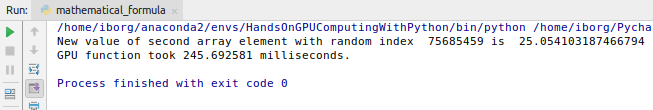

请注意，我们最初的公式很简单：

$$y = x \times y $$

这样做是为了用元素本身和另一个元素的乘积来更新元素数组。公式越复杂，计算就越密集。对于我们最近的计划，数学公式如下：

$$q = y^{2}cos^{2}x + sin(xy)$$

# 练习

数学方程式只有当你可以应用于解决社会问题，或者换句话说，通过计算服务于社会时才有用。我们通过多个跨学科领域的融合来做到这一点。

在尝试用计算方法解决问题之前，请始终考虑将问题分解为一系列分类步骤：
- 问题大纲：找出问题的本质，选择最有效的解决方法，并展示结果
- 问题解决：选择最有效的数学公式来解决问题
- 程序代码：对问题的基本解决方案进行编程
- 解决方案测试：应用前面的方法，用Python代码解决计算问题，提供有效的编程解决方案

例如，烟草与许多疾病有关，包括癌症。为了更好地理解这一点，我们可以尝试将烟草消费者与这些疾病的不同病例联系起来。因此，在这种情况下，我们的第一个数据集（数组）将是不同地区的烟草消费人口。我们的第二个数据集是同一地区的疾病病例。

通过PyCUDA，烟草与两种疾病相关：癌症和不孕症。使用卡尔-皮尔逊相关系数。

卡尔-皮尔逊相关系数是衡量两个变量之间线性关联强度的一种方法。它由r表示，从-1到+1变化。朝-1的值是负相关，朝+1的值是正相关。0表示不相关。
皮尔逊相关系数由以下公式表示：

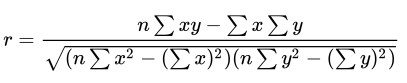

公式中的变量定义为：
- n是数据集中的值对数
- x和y是给定的一对值
- ∑xy是成对分数的乘积之和
- ∑x是第一个数据集的得分之和
- ∑y是第二个数据集的得分之和
- $∑x^2$是第一个数据集得分的平方和
- $∑y^2$是第二个数据集得分的平方和

请注意，计算代码中最密集的部分是$∑x、∑y、∑xy、∑x^2和∑y^2$。

规划问题的基本解决方案：
- 将同一地区内的烟草数据集与癌症数据集关联起来，按城市划分
- 将烟草数据集与同一地区内的不孕症数据集（按城市）相关联
- 使用随机值生成样本。如果可以，还可以尝试使用开放源代码数据库中的真实数据。

# 小结

在本章中，我们用一个比较的例子来说明CUDA代码的一般语法。在语法方面，引入了线程和块的概念。在一个现有的CUDA环境中说明了安装PyCUDA和Anaconda的步骤。如何建立PyCUDA被一步一步地解释。然后，我们学习了Python中计算的工作原理，并强调了计算问题解决的重要性。通过对PyCUDA和CUDA的比较，提出了并行归约的概念。

在这个阶段，您现在应该能够测试自己的CUDA程序。正如您在本书前面已经学习了如何安装CUDA一样，您还可以在现有CUDA环境中安装和配置PyCUDA。现在，您应该对计算问题解决的概念有了一些了解，它是计算的一种基本方法。现在，您可以开始尝试应用自己的公式来利用PyCUDA的gpu。强烈建议您现在进行有关卡尔·皮尔逊相关系数的练习，如本章最后一节所示。现在可以采用不同的方法来计算相关系数。

在下一章中，我们将深入探讨一个开源世界！我们将学习ROCm的异构计算和可移植性api，用于开源GPU计算，包括OpenCL。我们还将学习如何通过HIPify将CUDA程序转换为跨平台格式（HIP），可在NVIDIA和AMD GPU上使用。我们将了解NVIDIA GPU上的计算和AMD GPU上的计算之间的区别。下面将介绍一种深入的Python编程方法：PyOpenCL。